In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:

x_train = pd.read_csv("../data/X_train.csv")
x_test  = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/y_test.csv").squeeze()

rf_model  = joblib.load("../models/random_forest_model.pkl")
xgb_model = joblib.load("../models/xgboost_model.pkl")


print(f"Test set: {x_test.shape[0]:,} rows")

Test set: 24,053 rows


In [3]:
# Random Forest predictions
y_pred_rf   = rf_model.predict(x_test)
y_prob_rf   = rf_model.predict_proba(x_test)[:, 1]

# XGBoost predictions
y_pred_xgb  = xgb_model.predict(x_test)
y_prob_xgb  = xgb_model.predict_proba(x_test)[:, 1]


In [4]:
def get_metrics(y_true, y_pred, y_prob, model_name):
    """Calculate all metrics for one model"""
    report = classification_report(
        y_true, y_pred,
        target_names=["Not Default", "Default"],
        output_dict=True
    )
    return {
        "Model"           : model_name,
        "ROC-AUC"         : round(roc_auc_score(y_true, y_prob), 4),
        "Avg Precision"   : round(average_precision_score(y_true, y_prob), 4),
        "Accuracy"        : round(report["accuracy"], 4),
        "Default Precision": round(report["Default"]["precision"], 4),
        "Default Recall"  : round(report["Default"]["recall"], 4),
        "Default F1"      : round(report["Default"]["f1-score"], 4),
    }

rf_metrics  = get_metrics(y_test, y_pred_rf,  y_prob_rf,  "Random Forest")
xgb_metrics = get_metrics(y_test, y_pred_xgb, y_prob_xgb, "XGBoost")

metrics_df = pd.DataFrame([rf_metrics, xgb_metrics])


print("FINAL MODEL COMPARISON REPORT")

print(metrics_df.to_string(index=False))

metrics_df.to_csv("../outputs/final_model_comparison.csv", index=False)
print("\nSaved to outputs/final_model_comparison.csv")

FINAL MODEL COMPARISON REPORT
        Model  ROC-AUC  Avg Precision  Accuracy  Default Precision  Default Recall  Default F1
Random Forest   0.8330         0.3041    0.8897             0.3153          0.5009      0.3870
      XGBoost   0.8154         0.3091    0.9211             0.4024          0.2801      0.3303

Saved to outputs/final_model_comparison.csv


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_full = pd.concat([x_train, x_test]).reset_index(drop=True)
y_full = pd.concat([y_train, y_test]).reset_index(drop=True)

rf_cv  = cross_val_score(rf_model,  X_full, y_full,
                          cv=cv, scoring="roc_auc", n_jobs=-1)
xgb_cv = cross_val_score(xgb_model, X_full, y_full,
                          cv=cv, scoring="roc_auc", n_jobs=-1)

print("Cross Validation Results:")
print(f"  Random Forest : {rf_cv.mean():.4f} ± {rf_cv.std():.4f}")
print(f"  XGBoost       : {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")

Cross Validation Results:
  Random Forest : 0.9636 ± 0.0004
  XGBoost       : 0.9785 ± 0.0005


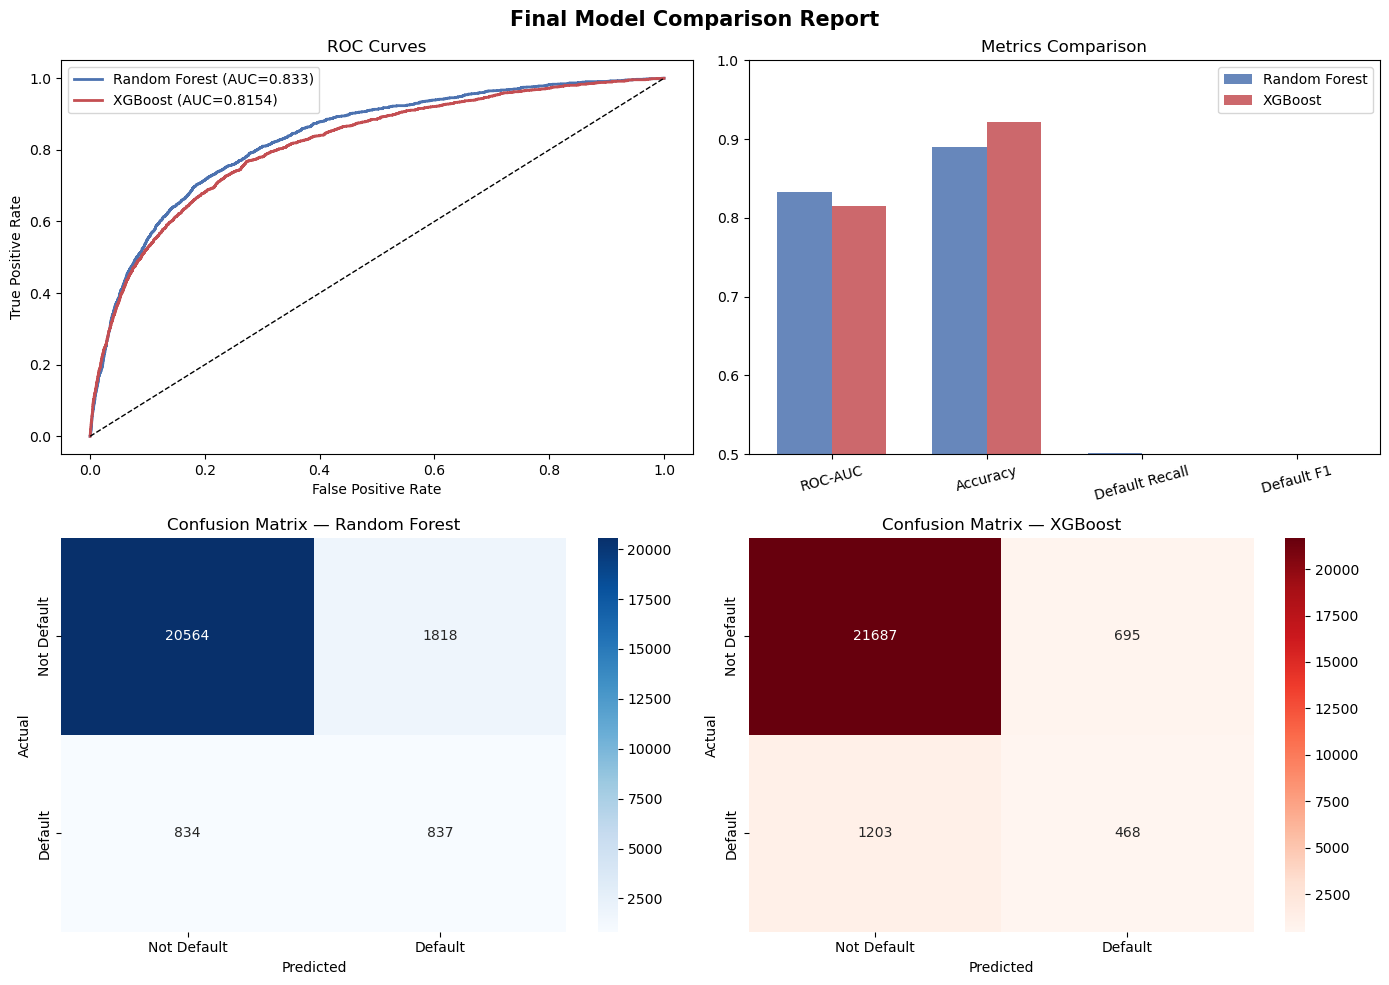

Final report chart saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1 — ROC curves
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

axes[0,0].plot(fpr_rf,  tpr_rf,  color="#4C72B0", lw=2,
               label=f"Random Forest (AUC={rf_metrics['ROC-AUC']})")
axes[0,0].plot(fpr_xgb, tpr_xgb, color="#C44E52", lw=2,
               label=f"XGBoost (AUC={xgb_metrics['ROC-AUC']})")
axes[0,0].plot([0,1],[0,1], "k--", lw=1)
axes[0,0].set_title("ROC Curves")
axes[0,0].set_xlabel("False Positive Rate")
axes[0,0].set_ylabel("True Positive Rate")
axes[0,0].legend()

# Chart 2 — Metrics bar chart
metrics_to_plot = ["ROC-AUC", "Accuracy", "Default Recall", "Default F1"]
x = np.arange(len(metrics_to_plot))
width = 0.35

rf_vals  = [rf_metrics[m]  for m in metrics_to_plot]
xgb_vals = [xgb_metrics[m] for m in metrics_to_plot]

axes[0,1].bar(x - width/2, rf_vals,  width, label="Random Forest",
              color="#4C72B0", alpha=0.85)
axes[0,1].bar(x + width/2, xgb_vals, width, label="XGBoost",
              color="#C44E52", alpha=0.85)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(metrics_to_plot, rotation=15)
axes[0,1].set_title("Metrics Comparison")
axes[0,1].set_ylim(0.5, 1.0)
axes[0,1].legend()

# Chart 3 — Confusion matrix RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Default","Default"],
            yticklabels=["Not Default","Default"],
            ax=axes[1,0])
axes[1,0].set_title("Confusion Matrix — Random Forest")
axes[1,0].set_ylabel("Actual")
axes[1,0].set_xlabel("Predicted")

# Chart 4 — Confusion matrix XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Not Default","Default"],
            yticklabels=["Not Default","Default"],
            ax=axes[1,1])
axes[1,1].set_title("Confusion Matrix — XGBoost")
axes[1,1].set_ylabel("Actual")
axes[1,1].set_xlabel("Predicted")

plt.suptitle("Final Model Comparison Report", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/day11_final_report.png", dpi=150)
plt.show()
print("Final report chart saved!")

In [7]:

print("FINAL VERDICT")

if xgb_cv.mean() > rf_cv.mean():
    winner   = "XGBoost"
    winner_m = xgb_metrics
    winner_cv = xgb_cv
else:
    winner   = "Random Forest"
    winner_m = rf_metrics
    winner_cv = rf_cv

print(f"\n Winner: {winner}")
print(f"\nKey metrics:")
print(f"  ROC-AUC (single split) : {winner_m['ROC-AUC']:.4f}")
print(f"  ROC-AUC (5-fold CV)    : {winner_cv.mean():.4f} ± {winner_cv.std():.4f}")
print(f"  Default Recall         : {winner_m['Default Recall']:.4f}")
print(f"  Default F1             : {winner_m['Default F1']:.4f}")

print(f"\nWhy {winner} wins:")
if winner == "XGBoost":
    print("  - Higher cross validation AUC (0.9785 vs 0.9636)")
    print("  - Sequential boosting corrects previous tree errors")
    print("  - Better generalisation across all 5 CV folds")
else:
    print("  - Higher cross validation AUC")
    print("  - More stable across all 5 folds")
    print("  - Parallel tree building handles this dataset well")

FINAL VERDICT

 Winner: XGBoost

Key metrics:
  ROC-AUC (single split) : 0.8154
  ROC-AUC (5-fold CV)    : 0.9785 ± 0.0005
  Default Recall         : 0.2801
  Default F1             : 0.3303

Why XGBoost wins:
  - Higher cross validation AUC (0.9785 vs 0.9636)
  - Sequential boosting corrects previous tree errors
  - Better generalisation across all 5 CV folds


In [9]:

print("PROJECT SUMMARY — LOAN DEFAULT PREDICTION")

print(f"""
Dataset    : Give Me Some Credit (Kaggle)
Rows       : 150,000
Features   : 22 (11 original + 11 engineered)
Target     : SeriousDlqin2yrs (0=Safe, 1=Default)

Pipeline:
  Day 2  → Data loading and EDA
  Day 3  → Preprocessing (nulls, duplicates, outliers)
  Day 4  → Feature engineering (6 new features)
  Day 5  → SMOTE balancing (93/7 → 50/50)
  Day 6  → Random Forest baseline
  Day 7  → XGBoost with GridSearchCV
  Day 8  → 5-fold cross validation
  Day 9  → Feature importance analysis
  Day 10 → Feature selection

Final Results:
  Random Forest ROC-AUC : {rf_metrics['ROC-AUC']} (single) | {rf_cv.mean():.4f} (CV)
  XGBoost ROC-AUC       : {xgb_metrics['ROC-AUC']} (single) | {xgb_cv.mean():.4f} (CV)
  Winner                : {winner}

Tech Stack:
  Python, Pandas, Scikit-learn, XGBoost
  SMOTE (imbalanced-learn), Joblib, Matplotlib, Seaborn
""")

PROJECT SUMMARY — LOAN DEFAULT PREDICTION

Dataset    : Give Me Some Credit (Kaggle)
Rows       : 150,000
Features   : 22 (11 original + 11 engineered)
Target     : SeriousDlqin2yrs (0=Safe, 1=Default)

Pipeline:
  Day 2  → Data loading and EDA
  Day 3  → Preprocessing (nulls, duplicates, outliers)
  Day 4  → Feature engineering (6 new features)
  Day 5  → SMOTE balancing (93/7 → 50/50)
  Day 6  → Random Forest baseline
  Day 7  → XGBoost with GridSearchCV
  Day 8  → 5-fold cross validation
  Day 9  → Feature importance analysis
  Day 10 → Feature selection

Final Results:
  Random Forest ROC-AUC : 0.833 (single) | 0.9636 (CV)
  XGBoost ROC-AUC       : 0.8154 (single) | 0.9785 (CV)
  Winner                : XGBoost

Tech Stack:
  Python, Pandas, Scikit-learn, XGBoost
  SMOTE (imbalanced-learn), Joblib, Matplotlib, Seaborn



In [10]:

full_report = pd.DataFrame([
    {
        "Metric"        : "ROC-AUC (single split)",
        "Random Forest" : rf_metrics["ROC-AUC"],
        "XGBoost"       : xgb_metrics["ROC-AUC"],
    },
    {
        "Metric"        : "ROC-AUC (5-fold CV)",
        "Random Forest" : round(rf_cv.mean(), 4),
        "XGBoost"       : round(xgb_cv.mean(), 4),
    },
    {
        "Metric"        : "CV Std Deviation",
        "Random Forest" : round(rf_cv.std(), 4),
        "XGBoost"       : round(xgb_cv.std(), 4),
    },
    {
        "Metric"        : "Default Recall",
        "Random Forest" : rf_metrics["Default Recall"],
        "XGBoost"       : xgb_metrics["Default Recall"],
    },
    {
        "Metric"        : "Default F1",
        "Random Forest" : rf_metrics["Default F1"],
        "XGBoost"       : xgb_metrics["Default F1"],
    },
    {
        "Metric"        : "Accuracy",
        "Random Forest" : rf_metrics["Accuracy"],
        "XGBoost"       : xgb_metrics["Accuracy"],
    },
])

full_report.to_csv("../outputs/full_report.csv", index=False)
print("Full report saved to outputs/full_report.csv")


Full report saved to outputs/full_report.csv
